# Temporal Trends Analysis

Analyze trends across the full time period (2010-2025).

**Focus Areas:**
- Trend lines for key metrics over 15+ years
- Acceleration/deceleration of disclosures
- Participation rate growth
- Evolution of reporting standards
- Year-over-year changes

## 1. Setup

In [2]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from data_engine.data_loader import CDPDataLoader
from utils import set_analysis_style

set_analysis_style()
loader = CDPDataLoader()

print("Setup complete!")

Setup complete!


## 2. Load Data Across All Years

In [3]:
# Get available years
years = loader.get_year_folders()
print(f"Years available: {years}\n")

# Create a structure to hold data across years
data_by_year = {}

print("Loading data for all years...")
for year in tqdm(years):
    data_by_year[year] = loader.load_year_data(year, category="all")

Years available: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Loading data for all years...


  0%|                                                                                                                                                                        | 0/16 [00:00<?, ?it/s]

Loaded: 2024_RawDataGlossary_Corporate_V1.1.xlsx - Shape: (0, 0)
Loaded: full_extract_cm_eds_c_isin_2024_responses_v1_20250623_125717.parquet - Shape: (10203898, 19)
Loaded: full_extract_cm_eds_c_isin_2024_summary_v1_20250623_125717.parquet - Shape: (12131, 29)
Loaded: full_extract_cm_eds_c_isin_2024_v1_20250623_125717_part01.xlsx - Shape: (12131, 30)
Loaded: full_extract_cm_eds_c_isin_2024_v1_20250623_125717_part02.xlsx - Shape: (12131, 30)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [01:33<00:00,  5.83s/it]

Loaded: full_extract_cm_eds_c_isin_2024_v1_20250623_125717_part03.xlsx - Shape: (12131, 30)


## 3. Temporal Analysis

In [4]:
# Example: Calculate dataset sizes over time
dataset_sizes = {}

for year, datasets in data_by_year.items():
    total_rows = 0
    count = 0
    for df in datasets.values():
        if df is not None and not df.empty:
            total_rows += len(df)
            count += 1
    dataset_sizes[year] = {'total_rows': total_rows, 'datasets': count}

# Convert to dataframe for visualization
size_df = pd.DataFrame(dataset_sizes).T
print(size_df)

      total_rows  datasets
2010           0         0
2011           0         0
2012           0         0
2013           0         0
2014           0         0
2015           0         0
2016           0         0
2017           0         0
2018           0         0
2019           0         0
2020           0         0
2021           0         0
2022           0         0
2023           0         0
2024    10252422         5
2025           0         0


## 4. Visualization

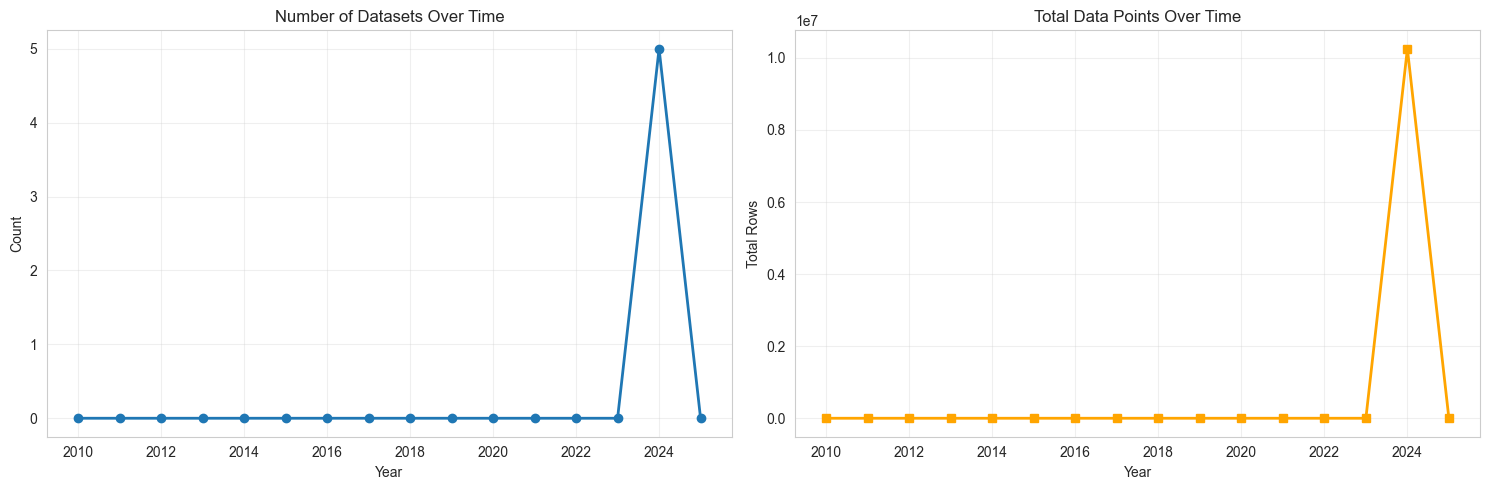

In [5]:
# Plot dataset growth over time
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Number of datasets
axes[0].plot(size_df.index, size_df['datasets'], marker='o', linewidth=2, markersize=6)
axes[0].set_title('Number of Datasets Over Time')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# Plot 2: Total rows
axes[1].plot(size_df.index, size_df['total_rows'], marker='s', linewidth=2, markersize=6, color='orange')
axes[1].set_title('Total Data Points Over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Rows')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Your Custom Temporal Analysis

Add additional trend analysis here...

In [6]:
# TODO: Add your temporal analysis
# - Merge and aggregate data across years
# - Identify companies participating over time
# - Track specific metrics longitudinally
# - Perform time-series analysis